# Kaggriculture
## 00 · Simulator and evaluation contract

A reproducible starting point for researching autonomous farming agents. This notebook verifies the problem, the official simulator, the evaluation boundary, and the first completed development episodes.

**Status:** foundation milestone. Feature research remains open; there is no trained competitive policy or official Kaggle rating.

### The decision problem

Two farms compete in a shared economy. Every turn, an agent allocates its farmer and hired workers, manages biological production, and places market orders. Final **banked coins** determine the winner. Unsold goods have no terminal value.

Kaggle ranks match outcomes, with a final Bradley–Terry evaluation. Local coin margins are diagnostics, and wins over a passive opponent are an engineering reference. [Official competition](https://www.kaggle.com/competitions/kaggriculture).

In [1]:
import json
from pathlib import Path

import pandas as pd
import plotly.graph_objects as go
from IPython.display import display

from kaggriculture_research.artifacts import digest, file_digest
from kaggriculture_research.environment import engine_manifest, read_protocol
from kaggriculture_research.visuals import show_figure

ROOT = Path.cwd() if (Path.cwd() / "configs").exists() else Path.cwd().parent
summary = json.loads((ROOT / "reports/foundation.json").read_text())
assert summary["engine"] == engine_manifest(), "Stale engine lineage"
assert summary["feature_lineage"]["feature_code"] == file_digest(
    ROOT / "src/kaggriculture_research/features.py"
), "Stale features"
assert summary["feature_lineage"]["audit_code"] == file_digest(
    ROOT / "src/kaggriculture_research/audit.py"
), "Stale audit"
assert summary["feature_lineage"]["protocol_sha256"] == digest(read_protocol(ROOT)), (
    "Stale protocol"
)
assert not summary["holdout_used"]

In [2]:
display(
    pd.DataFrame(
        {
            "Verified item": [
                "Official engine",
                "Recorded states per game",
                "Action rounds per game",
                "Completed development games",
                "Independent seeds",
                "Observed decisions (both agents)",
                "Kaggle rating",
                "Final optimization gate",
            ],
            "Result": [
                summary["engine"]["version"],
                summary["games"][0]["states"],
                summary["games"][0]["decision_steps"],
                summary["episodes"],
                summary["independent_development_seeds"],
                summary["callback_observations"],
                "Not submitted",
                "Closed",
            ],
        }
    ).set_index("Verified item")
)

,Result
Verified item,
Official engine,1.32.7
Recorded states per game,720
Action rounds per game,719
Completed development games,8
Independent seeds,4
Observed decisions (both agents),11504
Kaggle rating,Not submitted
Final optimization gate,Closed


### Evaluation contract

Four development seeds are played in both player positions. The seed is an experiment identifier only: the official engine removes it from the configuration given to the agent. Both seats remain together in later statistical comparisons. Separate validation and holdout seed pools are reserved.

The upstream `random` policy creates an unseeded RNG. The first reproducible reference therefore uses the deterministic official `starter` and `pass` agents. The default engine records 720 states including the initial state, and executes 719 action rounds; the horizon is unchanged.

In [3]:
games = pd.DataFrame(summary["games"])
display(
    games[
        [
            "seed",
            "starter_seat",
            "starter_win",
            "starter_tie",
            "coin_margin",
            "states",
            "decision_steps",
        ]
    ].rename(columns={"starter_seat": "starter seat", "coin_margin": "starter coin margin"})
)
assert all(status == ["DONE", "DONE"] for status in games["statuses"])

,seed,starter seat,starter_win,starter_tie,starter coin margin,states,decision_steps
0,1101,0,1.0,0.0,421.0,720,719
1,1101,1,1.0,0.0,421.0,720,719
2,1102,0,1.0,0.0,1054.0,720,719
3,1102,1,1.0,0.0,1054.0,720,719
4,1103,0,1.0,0.0,421.0,720,719
5,1103,1,1.0,0.0,421.0,720,719
6,1104,0,1.0,0.0,726.0,720,719
7,1104,1,1.0,0.0,726.0,720,719


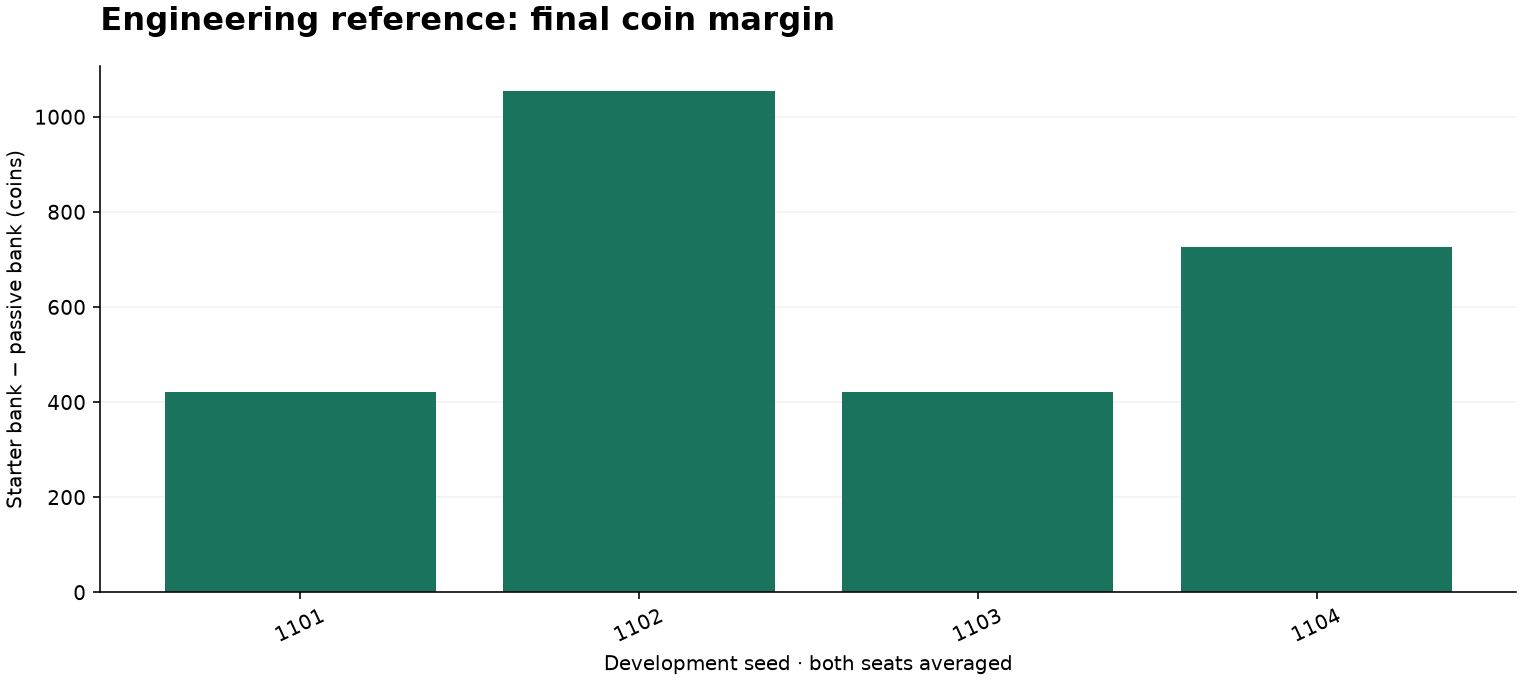

In [4]:
means = games.groupby("seed")["coin_margin"].mean()
fig = go.Figure(
    go.Bar(x=means.index.astype(str).tolist(), y=means.tolist(), name="Starter minus passive")
)
fig.update_layout(
    title="Engineering reference: final coin margin",
    xaxis_title="Development seed · both seats averaged",
    yaxis_title="Starter bank − passive bank (coins)",
)
show_figure(fig)

### What the reference does and does not show

A completed season with consistent rewards, zero failed agent statuses, and reproducible observations verifies the harness. The official starter manages a narrow carrot loop. These games do **not** establish opponent diversity, feature benefit, model quality, or leaderboard strength.

No candidate descriptor is consumed by either reference policy. Therefore no performance improvement can be attributed to the new feature extractor.

In [5]:
display(
    pd.Series(
        {
            "Local starter match score (win + 0.5 tie)": summary["reference_match_score"],
            "Mean starter coin margin": summary["mean_reference_coin_margin"],
            "Official leaderboard rating": "Not available",
            "Feature engineering effect": "Not measured",
            "Validation / holdout consumed": "Neither",
        },
        name="Reference result",
    ).to_frame()
)

,Reference result
Local starter match score (win + 0.5 tie),1.0
Mean starter coin margin,655.5
Official leaderboard rating,Not available
Feature engineering effect,Not measured
Validation / holdout consumed,Neither


### Reproducibility and persistence

Each episode checkpoint includes its engine and runner fingerprints, configuration, seed, player position, and a checksum. A separate semantic hash covers observations, actions, and rewards while excluding measured execution timing. Feature artifacts depend on the exact episode hashes and feature source.

The project has a dedicated SageMaker CPU space and private, encrypted, versioned S3 storage. A second run must reuse matching episodes. Full replay observations and feature matrices stay outside GitHub; small summaries support the review path.

In [6]:
display(pd.Series(summary["engine"]["files"], name="SHA-256").to_frame())

,SHA-256
agent.py,9b7682ce9921c8f34080a8be0f7b41598cc12ac7eb14d2...
core.py,0922c4599a1b6e0d8c3dadf06ae5297f98138d859d686f...
envs/kaggriculture/kaggriculture.json,a82c89c1a2315b93f39775d8e025471a01b738647c9772...
envs/kaggriculture/kaggriculture.py,bc8a54879ef02c7ea64b8b333d6a976f0ea65c4949149d...
schemas.json,cc6ccbca1a8f747e90434778f12acfe4b29bbeea69aeb5...
utils.py,537b627b11784d424147ef57ebb0369b039bf83c9f891e...


### Next: observation coverage

[Notebook 01](01_data_audit.ipynb) inventories the initial feature candidates and reveals where simple reference policies do not exercise the state space. Notebook `02` will be the research gate for richer action representations and controlled ablations.